# Prunable Neural Network with Sparsity Regularization (CIFAR-10)

This notebook trains a convolutional neural network with learnable gates that enable structured pruning. We explore the trade-off between accuracy and sparsity.

## 1.Install Dependencies

In [ ]:
!pip install tqdm seaborn tourch tourchvision matplotlib -q

## 2. Imports & Device Setup

IMPORTS AND DEVICE SETUP

We import PyTorch, torchvision, and visualization libraries.
We also select GPU if available for faster training.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

## 3. Prunable Linear Layer

This layer introduces gate scores that decide whether a weight should be active.

Each weight has a gate:
g = sigmoid(gate_scores)

Pruned weight:
W' = W * g

Output:
y = xW' + b

This allows the network to learn which weights to remove.

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # Standard weights and bias
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gates (control sparsity)
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        nn.init.kaiming_normal_(self.weight)
        nn.init.constant_(self.gate_scores, 2.0)  # start mostly "open"

    def forward(self, x):
        # Convert gate scores → [0,1]
        gates = torch.sigmoid(self.gate_scores)

        # Apply gates to weights
        return F.linear(x, self.weight * gates, self.bias)

## 4. Model Architecture

### We use:
- Convolution layers for feature extraction
- Residual blocks for better learning
- PrunableLinear layers for adaptive pruning

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, padding=1)  # first conv layer
        self.bn1 = nn.BatchNorm2d(c)  # normalization
        self.conv2 = nn.Conv2d(c, c, 3, padding=1)  # second conv layer
        self.bn2 = nn.BatchNorm2d(c)

    def forward(self, x):
        # residual connection helps gradient flow
        return F.relu(x + self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))


class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # input conv
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualBlock(32),  # residual block
            nn.MaxPool2d(2),  # downsample

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResidualBlock(64),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(64 * 8 * 8, 512)  # prunable dense layer
        self.dropout = nn.Dropout(0.3)  # regularization
        self.fc2 = PrunableLinear(512, 10)  # output layer

    def forward(self, x):
        x = self.conv(x)  # extract features
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))  # first FC layer
        x = self.dropout(x)
        return self.fc2(x)  # final logits

## 5. Sparsity Loss & Metrics

Encourages gates to close (i.e., prune weights).



Sparsity loss is used to encourage the model to turn off (prune) unnecessary connections.

Each weight in the prunable layer has a gate score g.
We pass this through a sigmoid function to convert it into a value between 0 and 1:

### sigmoid(g) = 1 / (1 + e^(-g))

If sigmoid(g) is close to 1 → the connection is active
If sigmoid(g) is close to 0 → the connection is effectively pruned

The sparsity loss is defined as the sum of all gate activations:

### L_sparsity = sum over all i of sigmoid(g_i)

Total Loss:
### L = CrossEntropy + λ * L_sparsity

Minimizing this loss pushes gate values toward 0, which encourages pruning and makes the network sparse.

In [ ]:
def sparsity_loss(model):
    loss = 0
    for m in model.modules():

        if isinstance(m, PrunableLinear):

            # Convert gate scores → probabilities (0 to 1)
            gates = torch.sigmoid(m.gate_scores)
            loss += gates.sum()

    return loss

def calculate_sparsity(model, threshold=1e-2):
    total, pruned = 0, 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):

            # Get gate activations
            g = torch.sigmoid(m.gate_scores)

            # Total number of gates (weights)
            total += g.numel()

            # Count how many are effectively "off"
            pruned += (g < threshold).sum().item()

    return 100 * pruned / total

## 6.Dataset Augmentation(CIFAR-10)

In [ ]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256)

## 7. Training Function

Includes:

Cross-entropy loss,
Sparsity regularization,
Learning rate scheduling


Lambda scheduling:
### λ = λ_max * (epoch / total_epochs)

This ensures:
- Early learning (low λ)
- Later pruning (high λ)

We evaluate:
- Test Accuracy
- Sparsity (% of pruned weights)

In [ ]:
def train(model, optimizer, scheduler, epoch, total_epochs, lambda_max):

    lam = lambda_max * (epoch / total_epochs)  # gradually increase lambda

    model.train()
    total_ce, correct, total = 0, 0, 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()  # reset gradients

        out = model(x)
        ce = F.cross_entropy(out, y)  # classification loss
        sp = sparsity_loss(model)  # sparsity penalty

        loss = ce + lam * sp  # total loss

        loss.backward()  # backpropagation
        optimizer.step()  # update parameters

        total_ce += ce.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    scheduler.step()  # update learning rate

    acc = 100 * correct / total
    sparsity = calculate_sparsity(model)

    print(f"Epoch [{epoch+1}/{total_epochs}] | "
          f"CE Loss: {total_ce/len(trainloader):.4f} | "
          f"Acc: {acc:.2f}% | "
          f"Sparsity: {sparsity:.2f}% | "
          f"λ: {lam:.6f}")

    return acc

## 8. Testing Function

In [ ]:
def test(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()

    return 100 * correct / total

## 9. Training Experiments

We test different sparsity strengths (λ values).

Using device: cuda

--- Training with Lambda = 1e-05 ---
Epoch [1/50] | CE Loss: 2.4182 | Acc: 23.97% | Sparsity: 0.00% | λ: 0.000000
Epoch [2/50] | CE Loss: 1.6747 | Acc: 37.91% | Sparsity: 0.00% | λ: 0.000000
Epoch [3/50] | CE Loss: 1.4966 | Acc: 45.25% | Sparsity: 0.00% | λ: 0.000000
Epoch [4/50] | CE Loss: 1.3169 | Acc: 52.38% | Sparsity: 0.00% | λ: 0.000001
Epoch [5/50] | CE Loss: 1.1815 | Acc: 57.51% | Sparsity: 0.00% | λ: 0.000001
Epoch [6/50] | CE Loss: 1.0862 | Acc: 61.18% | Sparsity: 0.00% | λ: 0.000001
Epoch [7/50] | CE Loss: 1.0072 | Acc: 64.39% | Sparsity: 0.00% | λ: 0.000001
Epoch [8/50] | CE Loss: 0.9593 | Acc: 66.25% | Sparsity: 0.00% | λ: 0.000001
Epoch [9/50] | CE Loss: 0.9128 | Acc: 67.71% | Sparsity: 0.00% | λ: 0.000002
Epoch [10/50] | CE Loss: 0.8674 | Acc: 69.47% | Sparsity: 3.53% | λ: 0.000002
Epoch [11/50] | CE Loss: 0.8368 | Acc: 70.59% | Sparsity: 8.18% | λ: 0.000002
Epoch [12/50] | CE Loss: 0.8137 | Acc: 71.47% | Sparsity: 12.14% | λ: 0.000002
Epoch [13/50] |

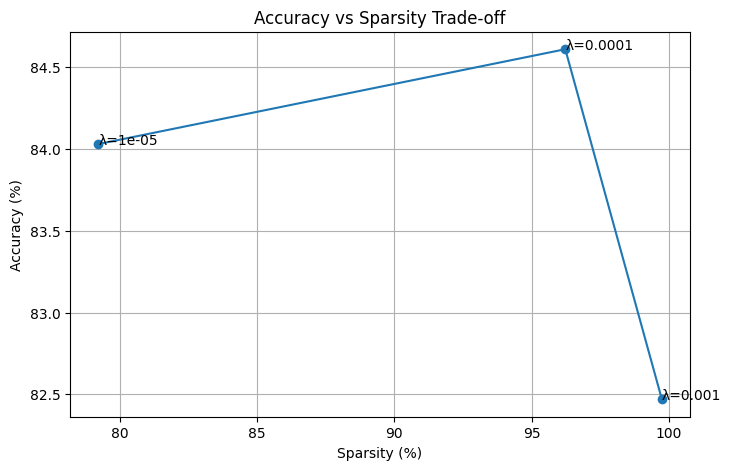

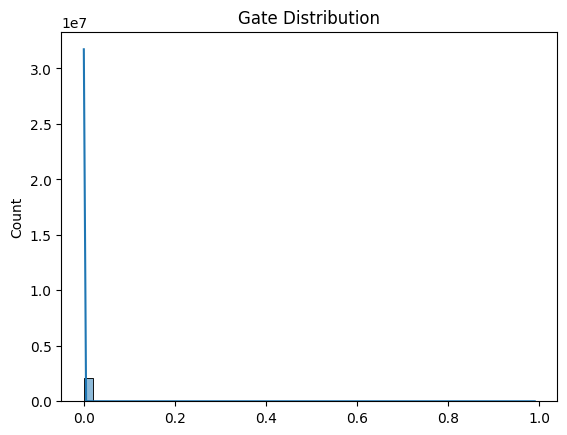

In [ ]:
lambda_values = [1e-5, 1e-4, 1e-3]
results = []
epochs = 50

for lam in lambda_values:
    print(f"\n--- Training with Lambda = {lam} ---")

    model = PrunableNet().to(device)

    # Separate gate and normal parameters
    gate_params = [m.gate_scores for m in model.modules() if isinstance(m, PrunableLinear)]
    other_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]

    optimizer = torch.optim.AdamW([
        {"params": other_params, "lr": 1e-3, "weight_decay": 1e-4},
        {"params": gate_params, "lr": 5e-3, "weight_decay": 0.0}
    ])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0
    best_model = None

    for epoch in range(epochs):
        acc = train(model, optimizer, scheduler, epoch, epochs, lam)

        if acc > best_acc:
            best_acc = acc
            best_model = model

    test_acc = test(best_model)
    sparsity = calculate_sparsity(best_model)

    print("\n✅ FINAL RESULTS")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    results.append((lam, test_acc, sparsity))

## 10. Results Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tradeoff_clean(results):
    lambdas = [r[0] for r in results]
    accuracy = np.array([r[1] for r in results])
    sparsity = np.array([r[2] for r in results])

    compression = np.array([1 / (1 - s/100 + 1e-6) for s in sparsity])

    plt.figure(figsize=(10,6))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Scatter
    scatter = plt.scatter(
        sparsity,
        accuracy,
        c=compression,
        cmap='viridis',
        s=180,
        edgecolors='black',
        zorder=3
    )

    # Connect points
    idx = np.argsort(sparsity)
    plt.plot(sparsity[idx], accuracy[idx], '--', color='gray', zorder=1)

    # ✅ AUTO CENTERING (IMPORTANT FIX)
    x_margin = (sparsity.max() - sparsity.min()) * 0.15
    y_margin = (accuracy.max() - accuracy.min()) * 0.15

    plt.xlim(sparsity.min() - x_margin, sparsity.max() + x_margin)
    plt.ylim(accuracy.min() - y_margin, accuracy.max() + y_margin)

    # Best accuracy line
    best_acc = accuracy.max()
    plt.axhline(best_acc, linestyle='dotted', color='green', alpha=0.7)
    plt.text(
        sparsity.min(),
        best_acc + 0.2,
        "Best Accuracy",
        color='green',
        fontsize=10
    )

    # ✅ SMART ANNOTATION (NO OVERLAP)
    offsets = [(10,10), (-80,10), (10,-40), (-80,-40)]

    for i, lam in enumerate(lambdas):
        offset = offsets[i % len(offsets)]

        plt.annotate(
            f"λ={lam}\n{accuracy[i]:.2f}% acc\n{sparsity[i]:.1f}% sparse\n{compression[i]:.1f}x",
            (sparsity[i], accuracy[i]),
            textcoords="offset points",
            xytext=offset,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
            arrowprops=dict(arrowstyle="->", lw=0.8)
        )

    # Labels
    plt.xlabel("Sparsity (%)", fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.title("Accuracy vs Sparsity Trade-off", fontsize=14)

    # Colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Compression Ratio (x)")

    plt.tight_layout()
    plt.show()

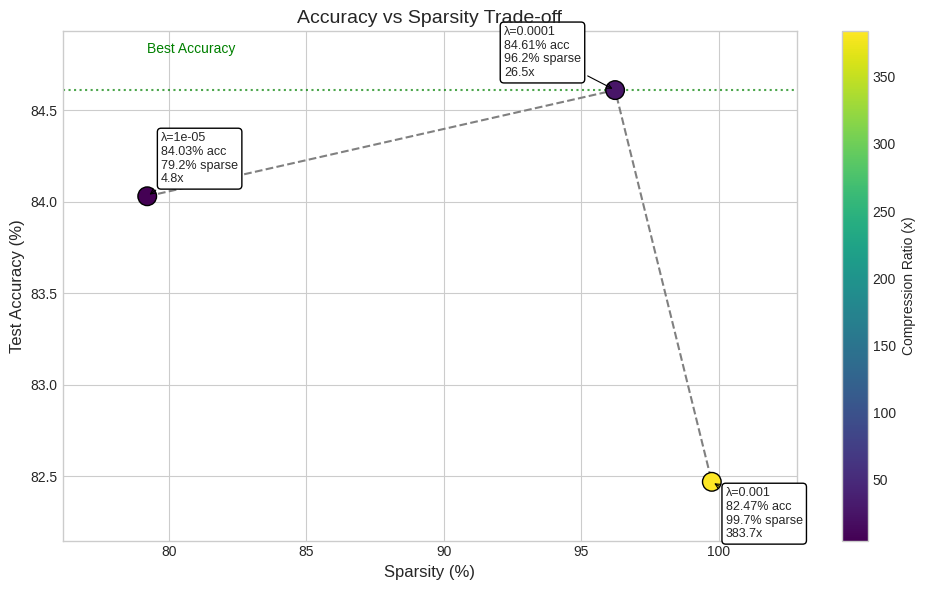

In [ ]:
plot_tradeoff_clean(results)

## 11. Gate Distribution

Visualizes how many weights are pruned.

In [ ]:
gates = []
for m in best_model.modules():
    if isinstance(m, PrunableLinear):
        gates.extend(torch.sigmoid(m.gate_scores).detach().cpu().numpy().flatten())

plt.figure()
sns.histplot(gates, bins=50, kde=True)
plt.title("Gate Distribution")
plt.show()